<a href="https://colab.research.google.com/github/dosb94/ml-movie-recommendation-system/blob/main/Movie_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-surprise pandas numpy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 3.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554966 sha256=22e5bee0005953facf378984611a1be65ad17fc4dc3da0eceb09423028502eaf
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [2]:
!wget https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
!unzip ml-latest-small.zip

--2026-04-28 22:32:50--  https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 978202 (955K) [application/zip]
Saving to: ‘ml-latest-small.zip’

ml-latest-small.zip 100%[===================>] 955.28K  4.38MB/s    in 0.2s    

2026-04-28 22:32:51 (4.38 MB/s) - ‘ml-latest-small.zip’ saved [978202/978202]

Archive:  ml-latest-small.zip
   creating: ml-latest-small/
  inflating: ml-latest-small/links.csv  
  inflating: ml-latest-small/tags.csv  
  inflating: ml-latest-small/ratings.csv  
  inflating: ml-latest-small/README.txt  
  inflating: ml-latest-small/movies.csv  


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
movies = pd.read_csv('ml-latest-small/movies.csv')
ratings = pd.read_csv('ml-latest-small/ratings.csv')

In [8]:
print("Shape:", movies.shape)
movies.head(5)

Shape: (9742, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [9]:
print("Genres sample:")
print(movies['genres'].unique()[:10])
print(f"\nTotal unique movies: {movies['movieId'].nunique()}")

Genres sample:
['Adventure|Animation|Children|Comedy|Fantasy'
 'Adventure|Children|Fantasy' 'Comedy|Romance' 'Comedy|Drama|Romance'
 'Comedy' 'Action|Crime|Thriller' 'Adventure|Children' 'Action'
 'Action|Adventure|Thriller' 'Comedy|Horror']

Total unique movies: 9742


In [10]:
print("Shape:", ratings.shape)
ratings.head(10)

Shape: (100836, 4)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
5,1,70,3.0,964982400
6,1,101,5.0,964980868
7,1,110,4.0,964982176
8,1,151,5.0,964984041
9,1,157,5.0,964984100


In [11]:
print(f"Total ratings: {len(ratings)}")
print(f"Total users: {ratings['userId'].nunique()}")
print(f"Total movies rated: {ratings['movieId'].nunique()}")
print(f"Rating min: {ratings['rating'].min()}")
print(f"Rating max: {ratings['rating'].max()}")
print(f"Rating average: {ratings['rating'].mean():.2f}")

Total ratings: 100836
Total users: 610
Total movies rated: 9724
Rating min: 0.5
Rating max: 5.0
Rating average: 3.50


/tmp/ipykernel_10335/2553703038.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings, palette='viridis')


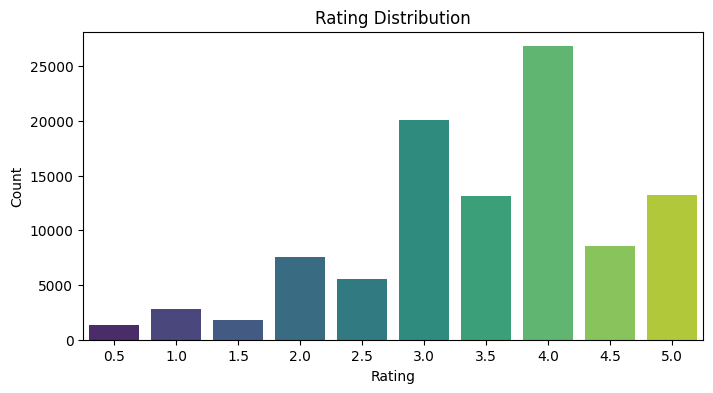

In [12]:
plt.figure(figsize=(8,4))
sns.countplot(x='rating', data=ratings, palette='viridis')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [13]:
top_movies = ratings.groupby('movieId')['rating'].count().reset_index()
top_movies.columns = ['movieId', 'num_ratings']
top_movies = top_movies.merge(movies, on='movieId')
top_movies = top_movies.sort_values('num_ratings', ascending=False).head(10)

print(top_movies[['title', 'num_ratings']])

                                          title  num_ratings
314                         Forrest Gump (1994)          329
277            Shawshank Redemption, The (1994)          317
257                         Pulp Fiction (1994)          307
510            Silence of the Lambs, The (1991)          279
1938                         Matrix, The (1999)          278
224   Star Wars: Episode IV - A New Hope (1977)          251
418                        Jurassic Park (1993)          238
97                            Braveheart (1995)          237
507           Terminator 2: Judgment Day (1991)          224
461                     Schindler's List (1993)          220


In [14]:
avg_ratings = ratings.groupby('movieId').agg(
    avg_rating=('rating', 'mean'),
    num_ratings=('rating', 'count')
).reset_index()

avg_ratings = avg_ratings[avg_ratings['num_ratings'] >= 50]
avg_ratings = avg_ratings.merge(movies, on='movieId')
avg_ratings = avg_ratings.sort_values('avg_rating', ascending=False).head(10)

print(avg_ratings[['title', 'avg_rating', 'num_ratings']])

                                                 title  avg_rating  \
53                    Shawshank Redemption, The (1994)    4.429022   
118                              Godfather, The (1972)    4.289062   
277                                  Fight Club (1999)    4.272936   
171                              Cool Hand Luke (1967)    4.271930   
112  Dr. Strangelove or: How I Learned to Stop Worr...    4.268041   
120                                 Rear Window (1954)    4.261905   
158                     Godfather: Part II, The (1974)    4.259690   
402                               Departed, The (2006)    4.252336   
153                                  Goodfellas (1990)    4.250000   
123                                  Casablanca (1942)    4.240000   

     num_ratings  
53           317  
118          192  
277          218  
171           57  
112           97  
120           84  
158          129  
402          107  
153          126  
123          100  


In [15]:
from sklearn.model_selection import train_test_split

# Merge ratings with movies
df = ratings.merge(movies, on='movieId')

# Encode userId and movieId as sequential integers
df['user'] = df['userId'].astype('category').cat.codes
df['movie'] = df['movieId'].astype('category').cat.codes

n_users = df['user'].nunique()
n_movies = df['movie'].nunique()

print(f"Number of users: {n_users}")
print(f"Number of movies: {n_movies}")

# Split data
train, test = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train size: {len(train)}")
print(f"Test size: {len(test)}")

Number of users: 610
Number of movies: 9724
Train size: 80668
Test size: 20168


In [16]:
import torch
import torch.nn as nn

In [17]:
#Definition of the model architecture
class CollaborativeFiltering(nn.Module):
    def __init__(self, n_users, n_movies, embedding_dim=50):
        super(CollaborativeFiltering, self).__init__()
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.movie_embedding = nn.Embedding(n_movies, embedding_dim)
        self.fc1 = nn.Linear(embedding_dim * 2, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

In [18]:
# Forward pass: defines how data flows through the model
def forward(self, user, movie):
        user_emb = self.user_embedding(user)
        movie_emb = self.movie_embedding(movie)
        x = torch.cat([user_emb, movie_emb], dim=1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x.squeeze()

In [19]:
# Initialize the model
model = CollaborativeFiltering(n_users, n_movies)
print(model)

CollaborativeFiltering(
  (user_embedding): Embedding(610, 50)
  (movie_embedding): Embedding(9724, 50)
  (fc1): Linear(in_features=100, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)


In [20]:
# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")

Loss function: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [21]:
# Convert data to PyTorch tensors
train_users = torch.LongTensor(train['user'].values)
train_movies = torch.LongTensor(train['movie'].values)
train_ratings = torch.FloatTensor(train['rating'].values)

test_users = torch.LongTensor(test['user'].values)
test_movies = torch.LongTensor(test['movie'].values)
test_ratings = torch.FloatTensor(test['rating'].values)

print(f"Train tensors ready: {train_users.shape}")
print(f"Test tensors ready: {test_users.shape}")

Train tensors ready: torch.Size([80668])
Test tensors ready: torch.Size([20168])


In [23]:
class CollaborativeFiltering(nn.Module):
    def __init__(self, n_users, n_movies, embedding_dim=50):
        super(CollaborativeFiltering, self).__init__()
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.movie_embedding = nn.Embedding(n_movies, embedding_dim)
        self.fc1 = nn.Linear(embedding_dim * 2, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, user, movie):
        # Forward pass: defines how data flows through the model
        user_emb = self.user_embedding(user)
        movie_emb = self.movie_embedding(movie)
        x = torch.cat([user_emb, movie_emb], dim=1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x.squeeze()

# Initialize the model
model = CollaborativeFiltering(n_users, n_movies)
print(model)

CollaborativeFiltering(
  (user_embedding): Embedding(610, 50)
  (movie_embedding): Embedding(9724, 50)
  (fc1): Linear(in_features=100, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)


In [24]:
# Training loop
epochs = 10
train_losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    predictions = model(train_users, train_movies)
    loss = criterion(predictions, train_ratings)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f}")

Epoch 1/10 - Loss: 12.4235
Epoch 2/10 - Loss: 12.4227
Epoch 3/10 - Loss: 12.4236
Epoch 4/10 - Loss: 12.4224
Epoch 5/10 - Loss: 12.4245
Epoch 6/10 - Loss: 12.4225
Epoch 7/10 - Loss: 12.4220
Epoch 8/10 - Loss: 12.4238
Epoch 9/10 - Loss: 12.4223
Epoch 10/10 - Loss: 12.4215


In [25]:
from torch.utils.data import DataLoader, TensorDataset

# Create datasets
train_dataset = TensorDataset(train_users, train_movies, train_ratings)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# Reinitialize model
model = CollaborativeFiltering(n_users, n_movies)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 10
train_losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_users, batch_movies, batch_ratings in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_users, batch_movies)
        loss = criterion(predictions, batch_ratings)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

Epoch 1/10 - Loss: 1.5350
Epoch 2/10 - Loss: 0.9364
Epoch 3/10 - Loss: 0.8734
Epoch 4/10 - Loss: 0.8324
Epoch 5/10 - Loss: 0.8004
Epoch 6/10 - Loss: 0.7779
Epoch 7/10 - Loss: 0.7519
Epoch 8/10 - Loss: 0.7372
Epoch 9/10 - Loss: 0.7168
Epoch 10/10 - Loss: 0.7050


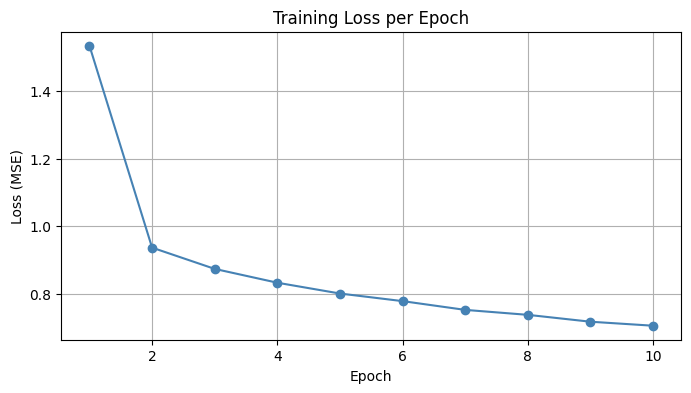

In [26]:
plt.figure(figsize=(8,4))
plt.plot(range(1, epochs+1), train_losses, marker='o', color='steelblue')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.show()

In [27]:
model.eval()
with torch.no_grad():
    test_predictions = model(test_users, test_movies)
    test_loss = criterion(test_predictions, test_ratings)
    rmse = torch.sqrt(test_loss)
    print(f"Test MSE: {test_loss.item():.4f}")
    print(f"Test RMSE: {rmse.item():.4f}")

Test MSE: 0.8099
Test RMSE: 0.8999


In [29]:
def recommend_movies(user_id, n_recommendations=10):
    model.eval()
    with torch.no_grad():
        rated_movies = ratings[ratings['userId'] == user_id]['movieId'].values
        unrated_movies = movies[~movies['movieId'].isin(rated_movies)]

        user_encoded = df[df['userId'] == user_id]['user'].values[0]
        movie_encoded = unrated_movies['movieId'].map(
            dict(zip(df['movieId'], df['movie']))
        ).dropna().astype(int)

        unrated_movies = unrated_movies.loc[movie_encoded.index]

        user_tensor = torch.LongTensor([user_encoded] * len(movie_encoded))
        movie_tensor = torch.LongTensor(movie_encoded.values)

        predictions = model(user_tensor, movie_tensor)

        # Clip predictions to valid rating range
        predictions = torch.clamp(predictions, min=0.5, max=5.0)

        unrated_movies = unrated_movies.copy()
        unrated_movies['predicted_rating'] = predictions.numpy()

        return unrated_movies.nlargest(n_recommendations, 'predicted_rating')[['title', 'genres', 'predicted_rating']]

print("Top 10 recommendations for User 1:")
print(recommend_movies(1))

Top 10 recommendations for User 1:
                                                 title  \
48                                     Lamerica (1994)   
211                          Heavenly Creatures (1994)   
602  Dr. Strangelove or: How I Learned to Stop Worr...   
661                                       Bound (1996)   
711                                   Notorious (1946)   
883                              Paths of Glory (1957)   
895                            Paris Is Burning (1990)   
924    Grand Day Out with Wallace and Gromit, A (1989)   
935                            Harold and Maude (1971)   
937    Seventh Seal, The (Sjunde inseglet, Det) (1957)   

                                         genres  predicted_rating  
48                              Adventure|Drama               5.0  
211                                 Crime|Drama               5.0  
602                                  Comedy|War               5.0  
661                Crime|Drama|Romance|Thriller       